In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

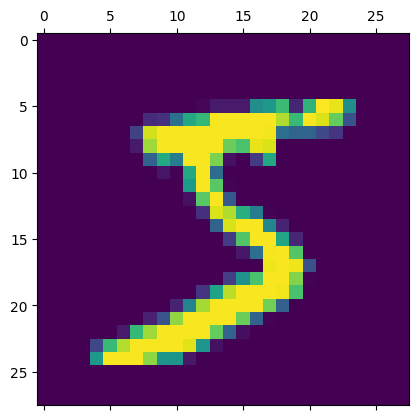

In [3]:
plt.matshow(X_train[0])

In [4]:
y_train[0]

np.uint8(5)

In [5]:
X_train = X_train / 255
X_test = X_test / 255

In [6]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [9]:

cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [10]:
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

model_fit = cnn_model.fit(X_train_reshaped, y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9520 - loss: 0.1560 - val_accuracy: 0.9793 - val_loss: 0.0724
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9836 - loss: 0.0537 - val_accuracy: 0.9836 - val_loss: 0.0534
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9890 - loss: 0.0367 - val_accuracy: 0.9867 - val_loss: 0.0453
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9910 - loss: 0.0271 - val_accuracy: 0.9884 - val_loss: 0.0428
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 31ms/step - accuracy: 0.9934 - loss: 0.0195 - val_accuracy: 0.9874 - val_loss: 0.0474


In [11]:
cnn_model.evaluate(X_test_reshaped, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9894 - loss: 0.0370


[0.03701546788215637, 0.9894000291824341]

In [12]:
y_pred = cnn_model.predict(X_test_reshaped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [13]:
y_pred_labels = [np.argmax(i) for i in y_pred]

In [14]:
y_pred_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [15]:
import numpy as np
predicted = np.argmax(y_pred[0])

In [16]:
predicted

np.int64(7)

In [17]:
y_pred[0]

array([6.6115692e-14, 1.2117157e-12, 1.6252033e-09, 9.5380559e-10,
       8.8632273e-16, 4.3187042e-15, 8.0598339e-19, 9.9999988e-01,
       1.4415830e-11, 1.4868235e-07], dtype=float32)

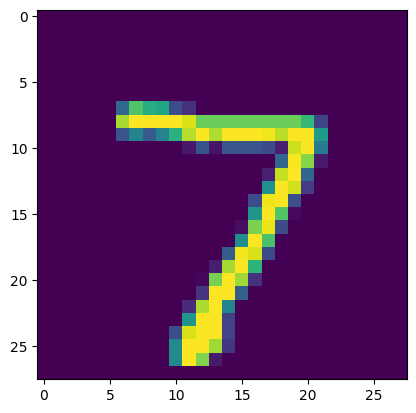

In [18]:
plt.imshow(X_test[0].reshape(28,28))
plt.show()

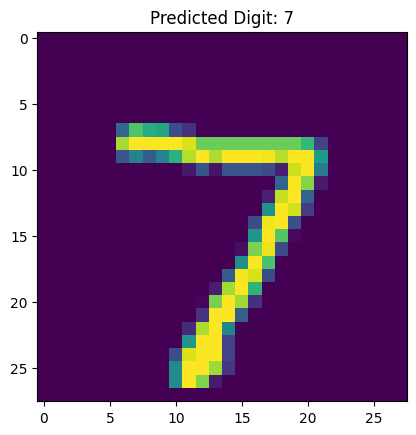

In [19]:
plt.imshow(X_test[0].reshape(28,28))

plt.title(f"Predicted Digit: {y_pred_labels[0]}")

plt.show()

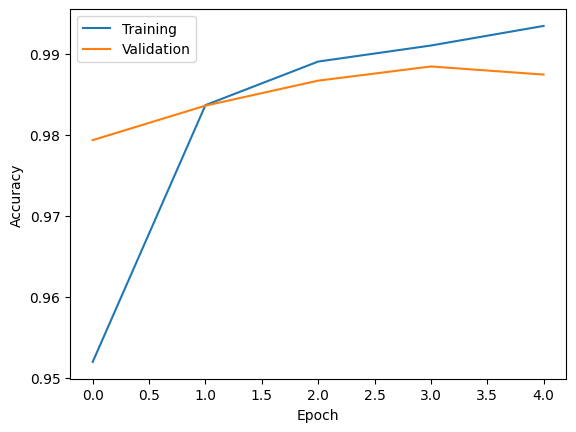

In [20]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training', 'Validation'])

plt.show()

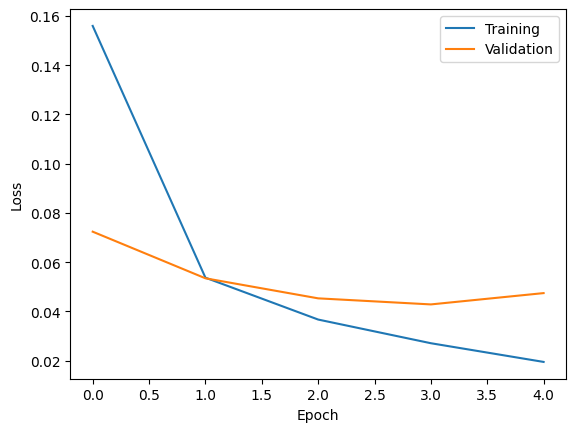

In [21]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training', 'Validation'])

plt.show()

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_labels)
cm

array([[ 976,    0,    0,    0,    0,    0,    2,    2,    0,    0],
       [   0, 1120,    2,    0,    3,    1,    4,    3,    1,    1],
       [   2,    0, 1019,    0,    2,    0,    0,    9,    0,    0],
       [   0,    0,    1,  993,    0,    8,    0,    5,    2,    1],
       [   0,    0,    0,    0,  978,    0,    0,    1,    1,    2],
       [   1,    0,    0,    3,    0,  885,    1,    1,    1,    0],
       [   3,    2,    0,    0,    2,    3,  944,    0,    4,    0],
       [   0,    0,    2,    0,    0,    0,    0, 1023,    1,    2],
       [   3,    0,    1,    1,    0,    2,    0,    3,  958,    6],
       [   1,    0,    0,    0,    3,    3,    0,    2,    2,  998]])

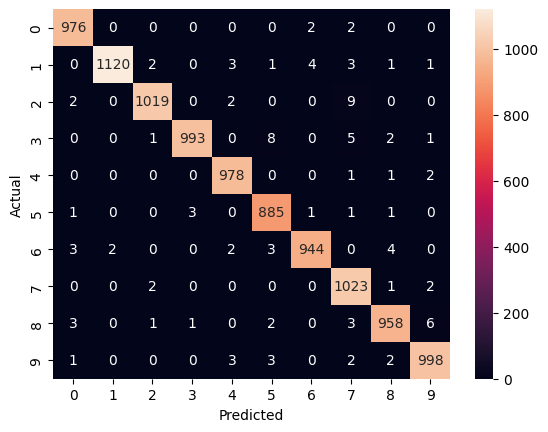

In [23]:
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()